In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

1. LOAD THE DATA

In [4]:
cus_data=pd.read_csv('customer_data.csv')
pay_data=pd.read_csv('payment_data.csv')


GLIMPSE THE DATA

In [5]:
print('Size of Customer data', cus_data.shape)
print('Size of Payment details', pay_data.shape)

Size of Customer data (1125, 13)
Size of Payment details (8250, 12)


In [6]:
cus_data.head(10)

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,5,151300,244.948974
1,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,3,341759,207.173840
2,0,58990862,7,1298.0,1,110000.0,2,11,-1,101,5,72001,1.000000
3,1,58995168,7,1335.5,1,151000.0,2,11,5,110,3,60084,1.000000
4,0,54987320,7,NaN,2,59000.0,2,11,5,108,4,450081,197.403141
5,0,59005995,6,1217.0,3,56000.0,2,6,-1,100,3,60091,1.000000
6,1,59001917,4,1304.0,3,35000.0,2,8,9,85,5,60069,1.000000
7,1,54984789,5,1256.0,3,78000.0,2,15,-1,111,3,60030,1.000000
8,0,58984557,5,1323.5,3,218000.0,2,15,5,112,4,151300,282.842713
9,0,54990497,4,NaN,2,35000.0,2,8,5,101,3,60029,237.301496


In [7]:
pay_data.head(10)

,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
0,58987402,0,0,0,0,1,10,16500.0,04/12/2016,0.0,NaN,NaN
1,58995151,0,0,0,0,1,5,NaN,04/12/2016,588720.0,491100.0,NaN
2,58997200,0,0,0,0,2,5,NaN,04/12/2016,840000.0,700500.0,22/04/2016
3,54988608,0,0,0,0,3,10,37400.0,03/12/2016,8425.2,7520.0,25/04/2016
4,54987763,0,0,0,0,2,10,NaN,03/12/2016,15147.6,NaN,26/04/2016
5,59004828,0,0,0,0,3,10,88000.0,02/12/2016,3196.8,6193.0,15/04/2016
6,58994429,0,0,0,0,2,10,16500.0,02/12/2016,3252.0,3210.0,NaN
7,54987756,0,0,0,0,2,1,NaN,02/12/2016,365331.6,304943.0,NaN
8,58988028,0,0,0,0,4,0,NaN,02/12/2016,16795.2,28500.0,19/04/2016
9,58993180,0,0,0,0,3,6,NaN,02/12/2016,26688.0,31300.0,20/03/2016


2. Exploratory data analysis (EDA) and statistics

In [8]:
# Merging the two datasets on 'id' column
from os.path import join
loan_train = cus_data.join(pay_data.set_index('id'), on='id', how='left', lsuffix='_cus', rsuffix='_pay')

In [9]:
#Some basic statistics of important contribution
loan_train.describe().T.round()

,count,mean,std,min,25%,50%,75%,max
label,8250.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
id,8250.0,57821730.0,1822724.0,54982353.0,54990497.0,58989048.0,58996551.0,59006239.0
fea_1,8250.0,6.0,1.0,1.0,4.0,5.0,7.0,7.0
fea_2,7222.0,1286.0,52.0,1116.0,1248.0,1283.0,1318.0,1481.0
fea_3,8250.0,2.0,1.0,1.0,1.0,3.0,3.0,3.0
fea_4,8250.0,138671.0,108157.0,15000.0,77000.0,111000.0,151000.0,1200000.0
fea_5,8250.0,2.0,0.0,1.0,2.0,2.0,2.0,2.0
fea_6,8250.0,11.0,3.0,3.0,8.0,11.0,12.0,16.0
fea_7,8250.0,5.0,3.0,-1.0,5.0,5.0,5.0,10.0
fea_8,8250.0,100.0,13.0,64.0,90.0,105.0,110.0,115.0


In [10]:
#check info for our columns
loan_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8250 entries, 0 to 1124
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            8250 non-null   int64  
 1   id               8250 non-null   int64  
 2   fea_1            8250 non-null   int64  
 3   fea_2            7222 non-null   float64
 4   fea_3            8250 non-null   int64  
 5   fea_4            8250 non-null   float64
 6   fea_5            8250 non-null   int64  
 7   fea_6            8250 non-null   int64  
 8   fea_7            8250 non-null   int64  
 9   fea_8            8250 non-null   int64  
 10  fea_9            8250 non-null   int64  
 11  fea_10           8250 non-null   int64  
 12  fea_11           8250 non-null   float64
 13  OVD_t1           8250 non-null   int64  
 14  OVD_t2           8250 non-null   int64  
 15  OVD_t3           8250 non-null   int64  
 16  OVD_sum          8250 non-null   int64  
 17  pay_normal       82

FIND SOME INTERESTING INSIGHTS OF THE DATASET

In [12]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

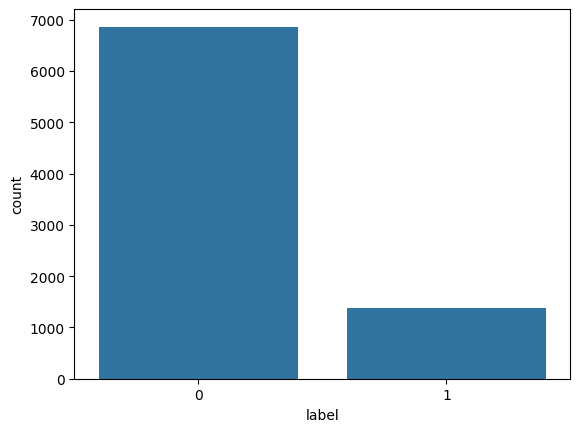

In [13]:
#check the distribution of our dependent variable
sns.countplot(x="label",data=loan_train)

Next, we will examine the correlation coefficients of the independent variables

<Axes: >

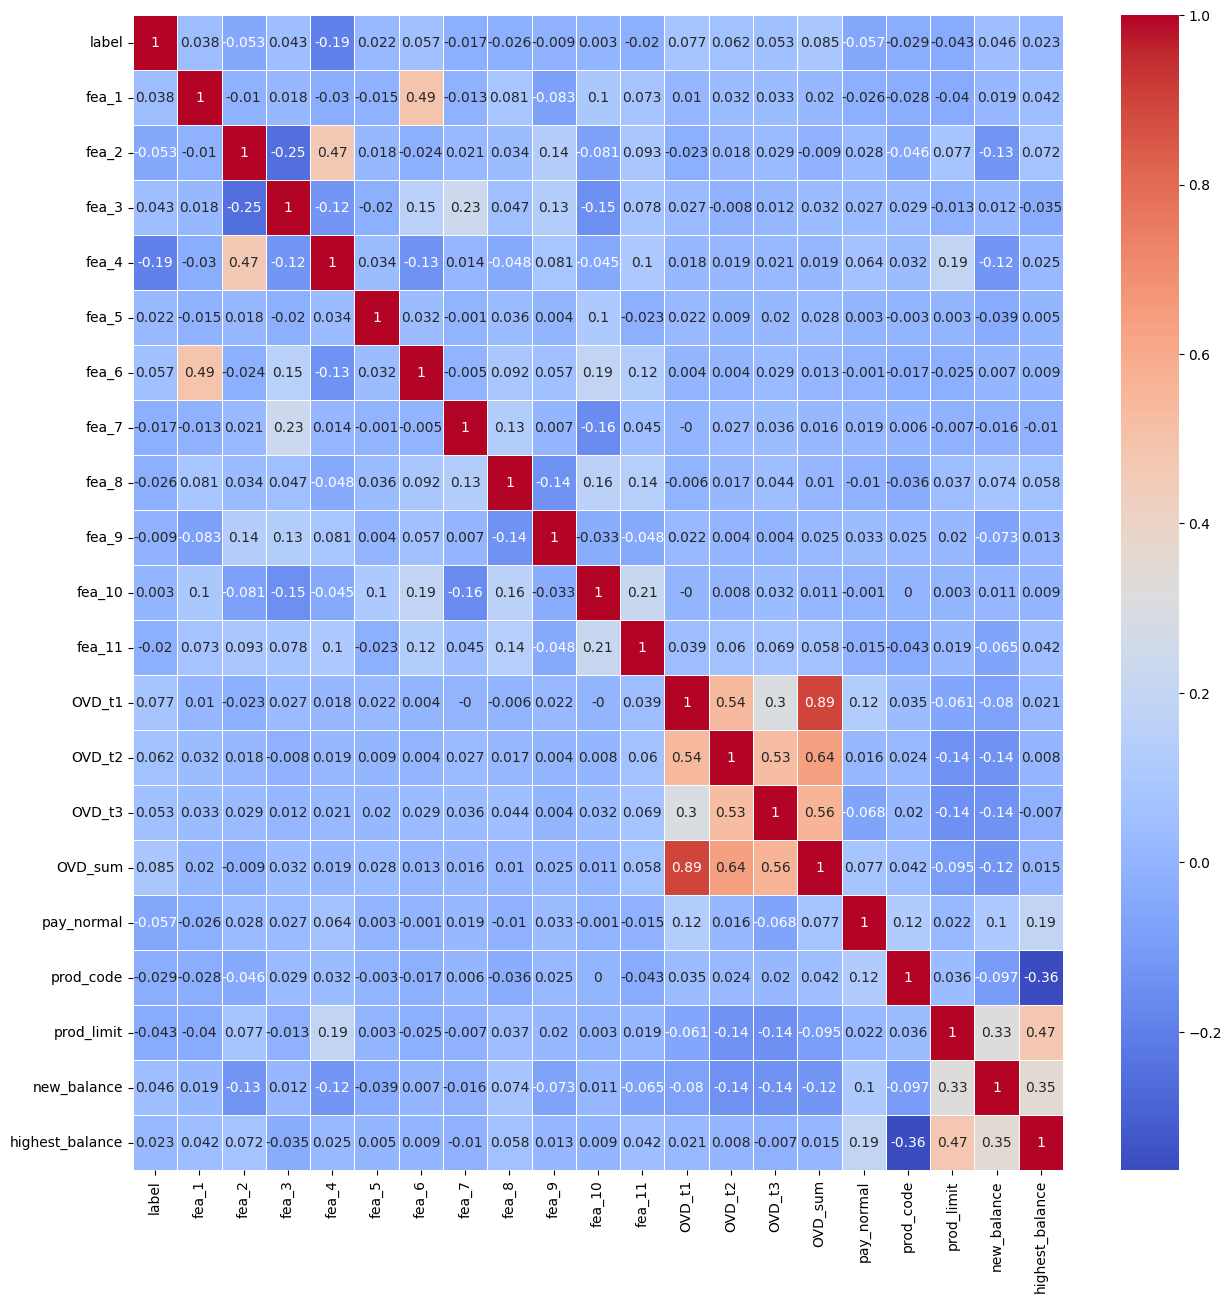

In [14]:
#correlation heatmap with spearman
plt.figure(figsize=(15,15))
# Drop non-numeric columns before calculating correlation
numeric_loan_train = loan_train.drop(columns=['update_date', 'report_date', 'id'])
sns.heatmap(numeric_loan_train.corr(method="spearman").round(3),cmap="coolwarm",lw=0.6,annot=True)


In [15]:
round(numeric_loan_train.corr(method="spearman")["label"].sort_values(ascending=False).drop("label"),2)

OVD_sum            0.09
OVD_t1             0.08
OVD_t2             0.06
fea_6              0.06
OVD_t3             0.05
new_balance        0.05
fea_3              0.04
fea_1              0.04
highest_balance    0.02
fea_5              0.02
fea_10             0.00
fea_9             -0.01
fea_7             -0.02
fea_11            -0.02
fea_8             -0.03
prod_code         -0.03
prod_limit        -0.04
fea_2             -0.05
pay_normal        -0.06
fea_4             -0.19
Name: label, dtype: float64

<Axes: >

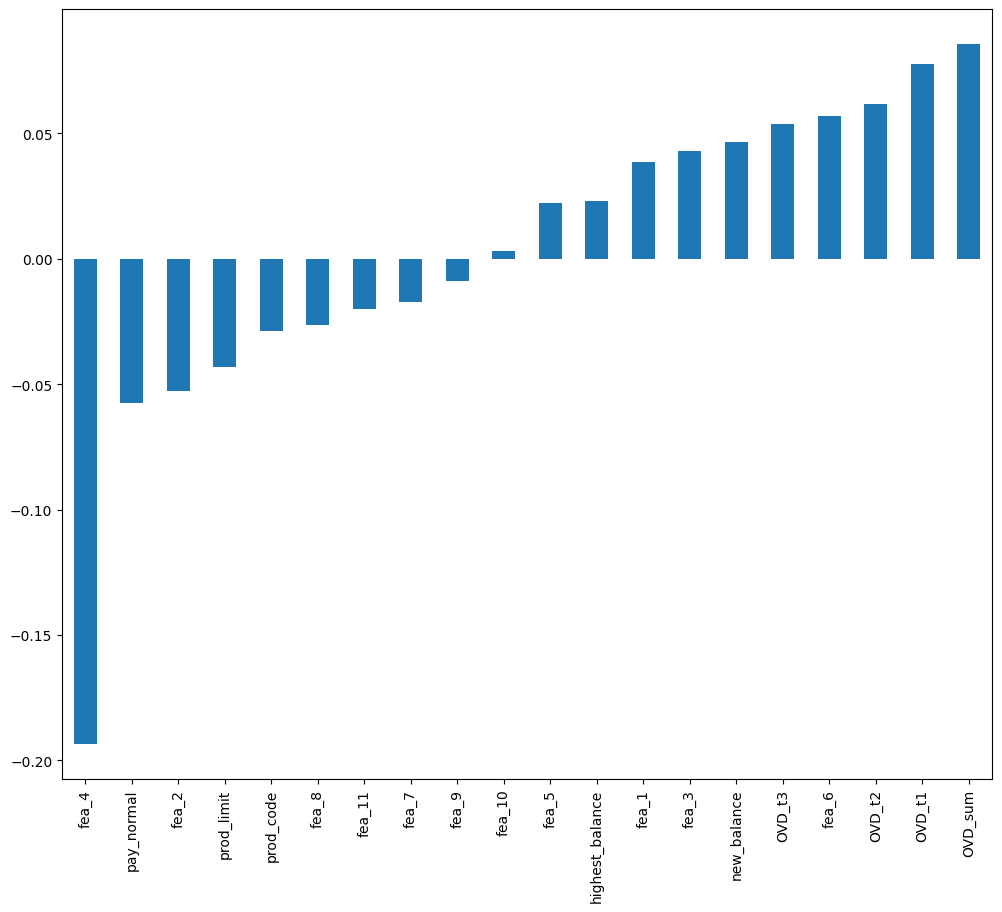

In [16]:
plt.figure(figsize=(12,10))
numeric_loan_train.corr(method="spearman")["label"].sort_values().drop("label").plot(kind="bar")
#In the below graph the difference is better depicted

3. DATA PREPROCESSING

In [17]:
#create a function for checking missing values
def get_missing_data(df):
  total=df.isnull().sum().sort_values(ascending=False)
  percent=(df.isnull().sum()/df.isnull().count()*100).sort_values(ascending=False)
  percent=round(percent,2)
  missing_df = pd.concat([total,percent],axis=1,keys=['Total','Percent'])
  print(missing_df.head(20))
  return None

In [18]:
get_missing_data(cus_data)

        Total  Percent
fea_2     149    13.24
label       0     0.00
id          0     0.00
fea_1       0     0.00
fea_3       0     0.00
fea_4       0     0.00
fea_5       0     0.00
fea_6       0     0.00
fea_7       0     0.00
fea_8       0     0.00
fea_9       0     0.00
fea_10      0     0.00
fea_11      0     0.00


In [19]:
get_missing_data(pay_data)

                 Total  Percent
prod_limit        6118    74.16
report_date       1114    13.50
highest_balance    409     4.96
update_date         26     0.32
OVD_t3               0     0.00
OVD_t2               0     0.00
OVD_t1               0     0.00
id                   0     0.00
prod_code            0     0.00
pay_normal           0     0.00
OVD_sum              0     0.00
new_balance          0     0.00


HANDLE THE MISSING VALUE

In [20]:
#combine 2 filesdataframes
merged_df = pd.merge(cus_data, pay_data, on='id', how='left')

In [21]:
merged_df['fea_2'].fillna(merged_df['fea_2'].median(), inplace=True)
merged_df['prod_limit'].fillna(merged_df['prod_limit'].median(), inplace=True)
merged_df['highest_balance'].fillna(merged_df['highest_balance'].median(), inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23000\3112666870.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['fea_2'].fillna(merged_df['fea_2'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23000\3112666870.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

AFTER HANDLING WE GET THE RESULT

In [22]:
print("Missing values:\n", merged_df.isnull().sum())

Missing values:
 label                 0
id                    0
fea_1                 0
fea_2                 0
fea_3                 0
fea_4                 0
fea_5                 0
fea_6                 0
fea_7                 0
fea_8                 0
fea_9                 0
fea_10                0
fea_11                0
OVD_t1                0
OVD_t2                0
OVD_t3                0
OVD_sum               0
pay_normal            0
prod_code             0
prod_limit            0
update_date          26
new_balance           0
highest_balance       0
report_date        1114
dtype: int64


DATA NORMALIZATION (IMPORTANT STEP)

In [23]:
#separating features and labels
labels = merged_df['label']
features = merged_df.drop(columns=['id', 'label', 'update_date', 'report_date'])  # 'id' and date columns are not features

In [24]:
from sklearn.preprocessing import StandardScaler #scikit-learn
# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


Here we can see the data after normalization.

In [25]:
# convert back to dataframe
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
# preview data after normalization
print("Dữ liệu đã chuẩn hóa:\n", features_scaled_df.head())

Dữ liệu đã chuẩn hóa:
       fea_1     fea_2     fea_3     fea_4    fea_5     fea_6     fea_7  \
0 -0.376487 -0.827401  0.766728 -0.570237  0.25074  1.479361  0.039222   
1 -0.376487 -0.827401  0.766728 -0.570237  0.25074  1.479361  0.039222   
2 -0.376487 -0.827401  0.766728 -0.570237  0.25074  1.479361  0.039222   
3 -0.376487 -0.827401  0.766728 -0.570237  0.25074  1.479361  0.039222   
4 -1.096806 -0.180086 -1.487148 -0.237366  0.25074 -1.118574 -1.939854   

      fea_8     fea_9    fea_10    fea_11    OVD_t1    OVD_t2    OVD_t3  \
0  0.715645  0.860908 -0.223178  0.752965 -0.199253 -0.147852 -0.127308   
1  0.715645  0.860908 -0.223178  0.752965 -0.199253 -0.147852 -0.127308   
2  0.715645  0.860908 -0.223178  0.752965 -0.199253 -0.147852 -0.127308   
3  0.715645  0.860908 -0.223178  0.752965 -0.199253  2.177745  8.837765   
4 -0.002098 -1.420650  0.917153  0.443523 -0.199253 -0.147852 -0.127308   

    OVD_sum  pay_normal  prod_code  prod_limit  new_balance  highest_balance  
0 

4. Build, train and evaluate models (random forest base on decs tree)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV #find optimal parameters 

Step 1: Split the data into training and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled_df, labels, test_size=0.2, random_state=42, stratify=labels
)

Step 2: Optimize the model

In [35]:
#Optimize Random Forest with Grid Search
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=1)
rf_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

Step 3: Select 1 parameter

In [36]:
# choose the best model
best_rf = rf_grid.best_estimator_
print("\nBest Random Forest Parameters:", rf_grid.best_params_)


Best Random Forest Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


Step 4: Make predictions on the test set (y_pred)

In [38]:
# Prediction on test set
y_pred = best_rf.predict(X_test)

EVALUATE THE MODEL

In [39]:
#evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1373    0]
 [  65  212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1373
           1       1.00      0.77      0.87       277

    accuracy                           0.96      1650
   macro avg       0.98      0.88      0.92      1650
weighted avg       0.96      0.96      0.96      1650


Accuracy Score: 0.9606060606060606


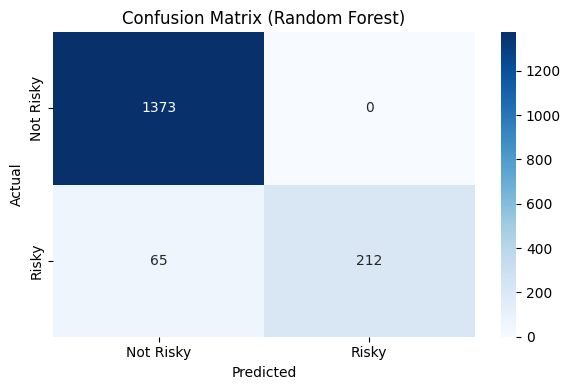

In [40]:
#visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Not Risky', 'Risky'], yticklabels=['Not Risky', 'Risky'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.tight_layout()
plt.show()

IMPORTANT FEATURES (CORRELATION)

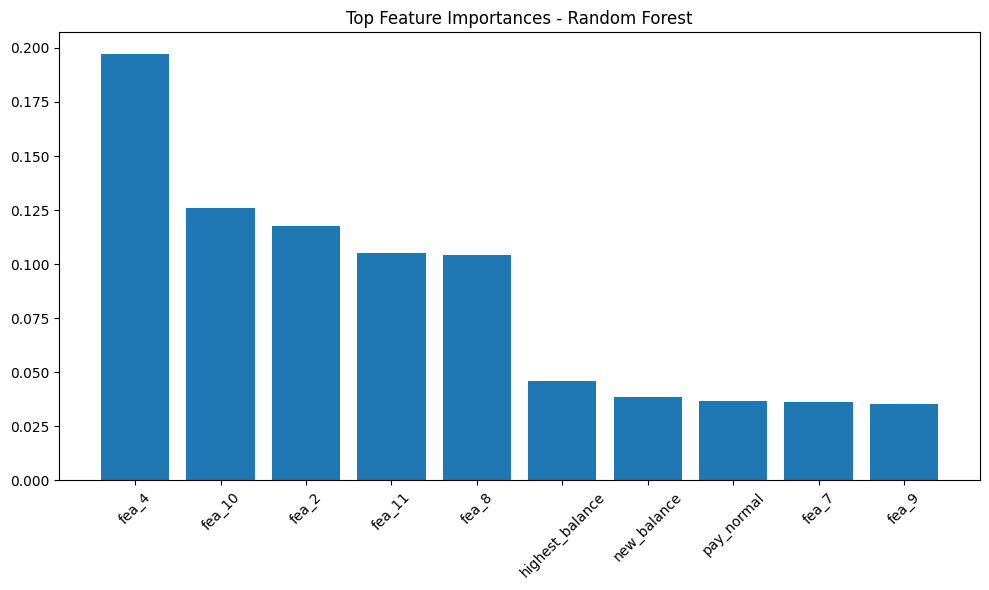

In [41]:
#arrange
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

#chart
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances - Random Forest")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), features_scaled_df.columns[indices[:10]], rotation=45)
plt.tight_layout()
plt.show()
